In [1]:
using LowLevelFEM, LinearAlgebra

[ Info: Precompiling LowLevelFEM [6171b9fb-adbf-4751-adb9-5faded75de07](cache misses: include_dependency fsize change (1), incompatible header (1), mismatched flags (1))
[ Info: Precompiling LowLevelFEM [6171b9fb-adbf-4751-adb9-5faded75de07] (cache misses: include_dependency fsize change (2), incompatible header (2), mismatched flags (2))

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


# Torsion of a prismatic bar using the Prandtl stress function

This example computes the torsional response of a prismatic bar by solving for the Prandtl stress function.

Unlike the displacement-based formulation of elasticity, torsion can be reduced to a scalar Poisson equation, making it an excellent example for demonstrating custom weak-form formulations.

## Geometry and finite element model

A rectangular cross-section is discretized using first-order quadrilateral elements.

The unknown is the scalar Prandtl stress function

$$
\psi(x,y),
$$

which is defined over the cross-section of the bar.

In [2]:
structured_rect_mesh(n=40, order=1)

mat = Material("body")
Pφ = Problem([mat], type=:ScalarField, dim=2, field=:φ, rhs_field=:p);

The shear modulus
$\mu$
is obtained from the material definition.

An external torque
$M_c$
is prescribed and will later be converted into the twist per unit length.

In [3]:
μ = mat.μ

Mc = 1;

## Weak formulation

For Saint-Venant torsion, the Prandtl stress function satisfies

$$
\nabla^2 \psi = -2
$$

inside the cross-section.

Its weak form is

$$
\int_\Omega
\nabla v \cdot \nabla \psi
\,d\Omega
=
\int_\Omega
2v
\,d\Omega .
$$

This system is assembled directly using the operator notation.

In [4]:
K = ∫(Grad(Pφ) ⋅ Grad(Pφ))

f = ∫(Pφ ⋅ (-2));

The stiffness matrix corresponds to the Laplace operator,

$$
K
=
\int_\Omega
\nabla v\cdot\nabla\psi\,d\Omega,
$$

while the right-hand side represents the constant source term associated with Saint-Venant torsion.

The Prandtl stress function vanishes on the boundary of the cross-section,

$$
\psi = 0.
$$

This homogeneous Dirichlet boundary condition ensures that the shear stresses are tangent to the boundary.

In [5]:
bcL = BoundaryCondition("left", φ=0)
bcR = BoundaryCondition("right", φ=0)
bcB = BoundaryCondition("bottom", φ=0)
bcT = BoundaryCondition("top", φ=0);

In [6]:
ψ = solveField(K, f, support=[bcL, bcR, bcB, bcT]);

After solving the Poisson equation, the resulting field is the normalized Prandtl stress function.

In [7]:
showDoFResults(ψ, name="ψ", visible=true);

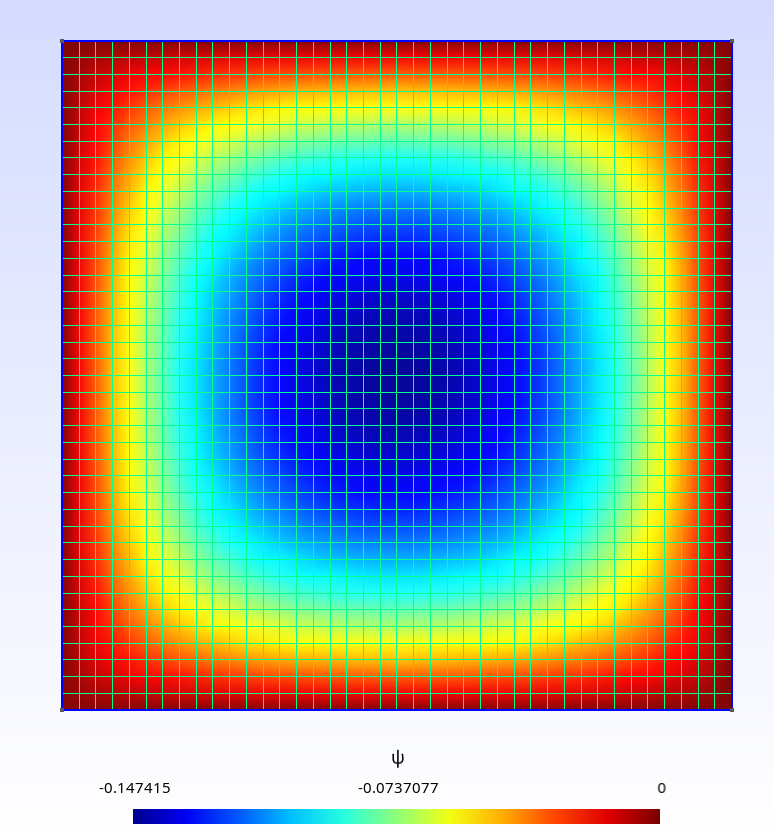

## Torsional constant

The torsional constant is computed from

$$
I_c
=
2
\int_\Omega
\psi
\,d\Omega.
$$

This quantity depends only on the geometry of the cross-section.

In [8]:
Ic = 2 * ∫(Pφ, "body", ψ)

-0.14044609426518706

For a prescribed torque

$$
M_c,
$$

the twist per unit length is

$$
\beta
=
\frac{M_c}{\mu I_c}.
$$

In [9]:
β = Mc / (μ * Ic)

-9.256220379794758e-5

The stress function is finally scaled according to the prescribed loading,

$$
\Phi
=
\mu\beta\psi \vec e_z.
$$

Its gradient directly determines the shear stress field.

In [10]:
ϕ = μ * β * ψ

Φ = VectorField(Pφ, "body", [0, 0, ϕ]);

## Shear stress distribution

The shear stress vector is obtained as

$$
\boldsymbol{\tau}
=
\nabla \times \Phi,
$$

which automatically satisfies equilibrium.

The resulting stresses are tangent to the boundary and reproduce the classical Saint-Venant solution for a rectangular cross-section.

In [11]:
τ = ∇ × Φ;

In [12]:
showDoFResults(τ, name="τ");

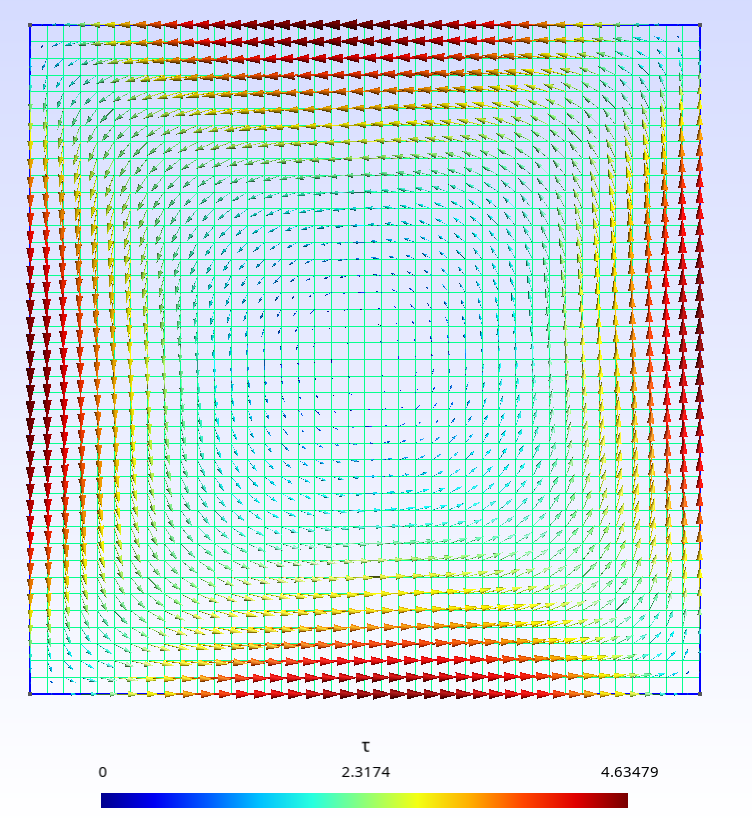

## Summary

This example demonstrates how a classical torsion problem can be formulated directly from its governing partial differential equation.

Although derived from elasticity theory, the implementation involves only standard differential operators, highlighting the flexibility of the weak-form interface in LowLevelFEM.

In [13]:
openPostProcessor()

XOpenIM() failed
Fontconfig warning: using without calling FcInit()
